In [1]:
from datetime import date, timedelta
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
cl = lambda x : x.drop('Unnamed: 0',axis=1,inplace=True)

In [3]:
forecasted = pd.read_csv('forecast_22072025.csv')
cl(forecasted)
forecasted.Material=forecasted.Material.astype(str)

In [4]:
forecasted.leadtime = forecasted.leadtime.astype(int)

In [5]:
forecasted.head()

,Material,Desc,leadtime,max_leadtime,year,forecasted_consum,Regular_req,One-off_req,Anticipated_consum,Buffer_stock,on_order_stock,Present_stock,net_req,oem
0,100000705,GAS REFRIGERATION 404A,100,100,2025,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
1,100000705,GAS REFRIGERATION 404A,100,100,2026,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
2,100000705,GAS REFRIGERATION 404A,100,100,2027,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
3,100000705,GAS REFRIGERATION 404A,100,100,2028,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
4,100000705,GAS REFRIGERATION 404A,100,100,2029,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN


In [6]:
forecasted.oem.value_counts()

oem
atlas    110
ksb      100
Name: count, dtype: int64

In [21]:
def makedaywiseForecast(df_yearly,mat,oem,end_date=date.today()+timedelta(days=365*5),initial_stock=10):
    daywiseForecast = pd.DataFrame(columns=['Material','Desc','leadtime','date','daily_cons','Regular_req', 'One-off_req','Anticipated_consum','Buffer_stock','on_order_stock','present_stock','stock_after'])
    df=df_yearly.copy()
    df=df[(df['Material']==mat)&(df['oem']==oem)].reset_index(drop=True)
    consider_pre_order = False
    start_date = date.today()
    days = (end_date-start_date).days
    initial_stock = df.at[0,'forecasted_consum']*2
    daywiseForecast.at[0,'present_stock'] = initial_stock if df.at[0,'Buffer_stock'] < initial_stock else df.at[0,'Buffer_stock']*1.4
    daywiseForecast.at[0,'stock_after']=daywiseForecast.at[0,'present_stock']
    reorder_point=end_date+timedelta(days=2)
    reorder_qty,updated_reorder_qty=0,0
    first_reorder=False
    leadtime = df['leadtime'].iloc[0]
    arrival={}
    for i in range(days):
        daywiseForecast.at[i,'date']=start_date+timedelta(days=i)
        daywiseForecast.at[i,'Anticipated_consum']=df.loc[df['year']==date.today().year,'Anticipated_consum'].iloc[0]
        daywiseForecast.at[i,'Regular_req']=df.loc[df['year']==date.today().year,'Regular_req'].iloc[0]
        daywiseForecast.at[i,'One-off_req']=df.loc[df['year']==date.today().year,'One-off_req'].iloc[0]
        daywiseForecast.at[i,'Buffer_stock']=df.loc[df['year']==date.today().year,'Buffer_stock'].iloc[0]
        daywiseForecast.at[i,'daily_cons']=df.loc[df['year']==date.today().year,'forecasted_consum'].iloc[0]/365
        if i>0:
            if i in arrival.keys():
                arrived_qty = arrival[i]
            else:
                arrived_qty=0
            daywiseForecast.at[i,'present_stock']=max(daywiseForecast.at[i-1,'present_stock']-daywiseForecast.at[i-1,'daily_cons'],0)
            daywiseForecast.at[i,'stock_after']=max(daywiseForecast.at[i-1,'stock_after']-daywiseForecast.at[i-1,'daily_cons'],0)+arrived_qty
            #print(daywiseForecast.at[i,'present_stock'],daywiseForecast.at[i,'stock_after'])
            if not first_reorder:
                if daywiseForecast.at[i,'present_stock']< daywiseForecast.at[i,'Buffer_stock']:
                    reorder_point = daywiseForecast.at[i,'date']
                    first_reorder = True
                    current_year=daywiseForecast.at[i,'date'].year
                    reorder_qty = daywiseForecast.at[i,'One-off_req']+ daywiseForecast.at[i,'Regular_req'] + daywiseForecast.at[i,'Anticipated_consum'] +  daywiseForecast.at[i,'Buffer_stock'] - daywiseForecast.at[i, 'present_stock']
                    arrival[i+leadtime]=reorder_qty
    daywiseForecast['Material']=mat
    daywiseForecast['Desc']=df.at[0,'Desc']
    daywiseForecast['leadtime']=df['leadtime'].iloc[0]
    date_for_stock_check = reorder_point+timedelta(days=(365+int(leadtime)))
    if date_for_stock_check < end_date:
        if daywiseForecast[daywiseForecast['date']==date_for_stock_check]['present_stock'].iloc[0] == 0:
            consider_pre_order = True
            updated_period = daywiseForecast[daywiseForecast['date'].between(date.today(),reorder_point)]
            updated_reorder_qty = reorder_qty - updated_period['daily_cons'].values.sum()
    return daywiseForecast.reset_index(drop=True),{'reorder_point':reorder_point,'reorder_qty': np.ceil(reorder_qty),'updated_reorder_qty':np.ceil(updated_reorder_qty),'consider_pre_order':consider_pre_order}

In [10]:
df,results = makedaywiseForecast(forecasted,'220003196','atlas')

In [11]:
df

,Material,Desc,leadtime,date,daily_cons,Regular_req,One-off_req,Anticipated_consum,Buffer_stock,on_order_stock,present_stock,stock_after
0,220003196,OIL FILTER,710,2025-07-22,0.035329,12.0,12.895051,48.425991,27.203259,NaN,32.643911,32.643911
1,220003196,OIL FILTER,710,2025-07-23,0.035329,12.0,12.895051,48.425991,27.203259,NaN,32.608582,32.608582
2,220003196,OIL FILTER,710,2025-07-24,0.035329,12.0,12.895051,48.425991,27.203259,NaN,32.573253,32.573253
3,220003196,OIL FILTER,710,2025-07-25,0.035329,12.0,12.895051,48.425991,27.203259,NaN,32.537924,32.537924
4,220003196,OIL FILTER,710,2025-07-26,0.035329,12.0,12.895051,48.425991,27.203259,NaN,32.502595,32.502595
...,...,...,...,...,...,...,...,...,...,...,...,...
1820,220003196,OIL FILTER,710,2030-07-16,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,41.701669
1821,220003196,OIL FILTER,710,2030-07-17,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,41.66634
1822,220003196,OIL FILTER,710,2030-07-18,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,41.631011
1823,220003196,OIL FILTER,710,2030-07-19,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,41.595682


In [12]:
results

{'reorder_point': datetime.date(2025, 12, 24),
 'reorder_qty': 74.0,
 'updated_reorder_qty': 68.0,
 'consider_pre_order': True}

In [13]:
def plot_req2(dff,tagw,mat,ro_p,leadtime):
  result=dff.copy()
  plt.figure(figsize=(12, 4))
  for t in tagw:
    t1=result[t].to_list()
    y1=result['date'].to_list()
    plt.plot(y1,t1, label=t,marker='o', linestyle='-')
  plt.axvline(x=ro_p, color='red', linestyle='--', label=f"reorder point at {ro_p.strftime('%d-%m-%Y')}")
  plt.axvline(x=ro_p+timedelta(days=leadtime), color='red', linestyle='--', label=f"delivery point at {(ro_p+timedelta(days=leadtime)).strftime('%d-%m-%Y')}")
  plt.hlines(max(t1), ro_p, ro_p+timedelta(days=leadtime), colors='k', linestyles='--', label='leadtime')
  plt.xticks(ticks=y1, labels=y1, rotation=45)
  plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  plt.legend()
  plt.title(f"Forecast - {mat}")
  plt.tight_layout()
  plt.savefig(f"{mat}_1.png")
  plt.show()

In [14]:
ordering_required = {}
for mat in forecasted[forecasted.oem=='atlas'].Material.unique():
    _, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'atlas')

ordering_required

{'220003196': {'reorder_point': datetime.date(2025, 12, 24),
  'reorder_qty': 74.0,
  'updated_reorder_qty': 68.0,
  'consider_pre_order': True},
 '220026293': {'reorder_point': datetime.date(2030, 7, 23),
  'reorder_qty': 0.0,
  'updated_reorder_qty': 0.0,
  'consider_pre_order': False},
 '220027684': {'reorder_point': datetime.date(2025, 11, 24),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220035026': {'reorder_point': datetime.date(2026, 2, 15),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220035027': {'reorder_point': datetime.date(2026, 2, 15),
  'reorder_qty': 2.0,
  'updated_reorder_qty': 2.0,
  'consider_pre_order': True},
 '220035032': {'reorder_point': datetime.date(2025, 8, 27),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220038299': {'reorder_point': datetime.date(2026, 1, 10),
  'reorder_qty': 2.0,
  'updated_reorder_qty': 2.0,
  'consider_pre_order': T

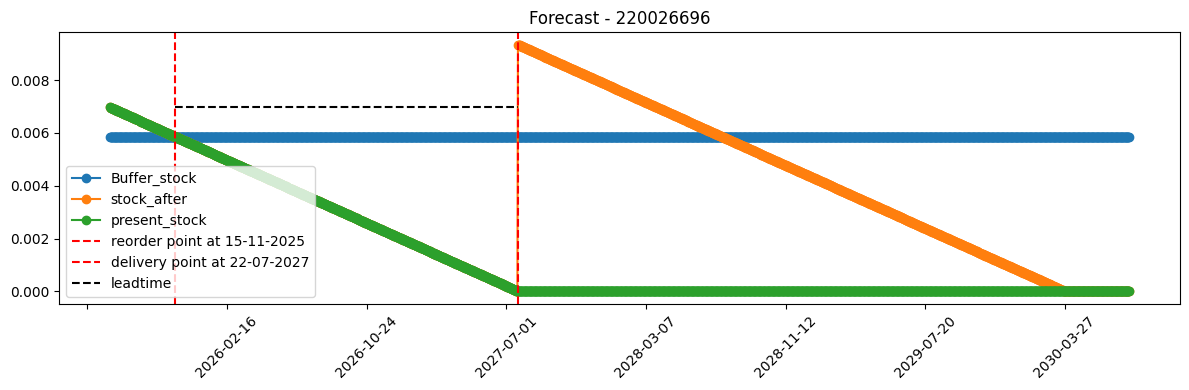

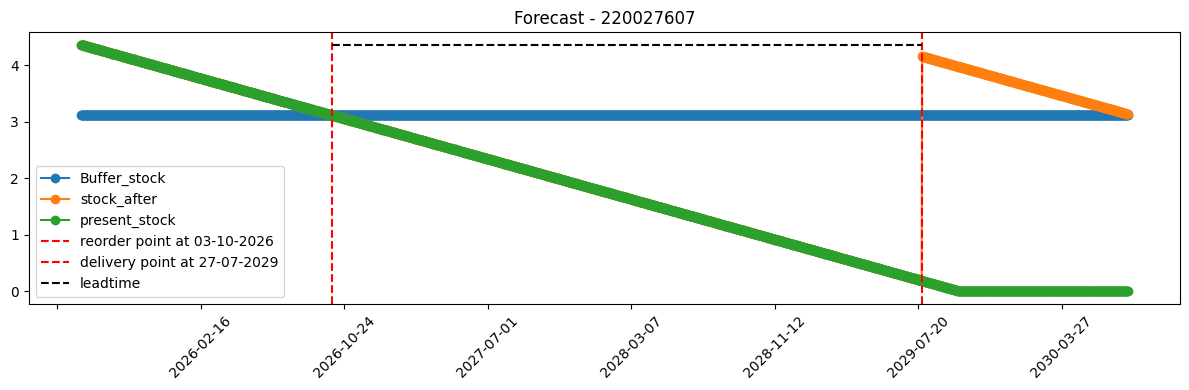

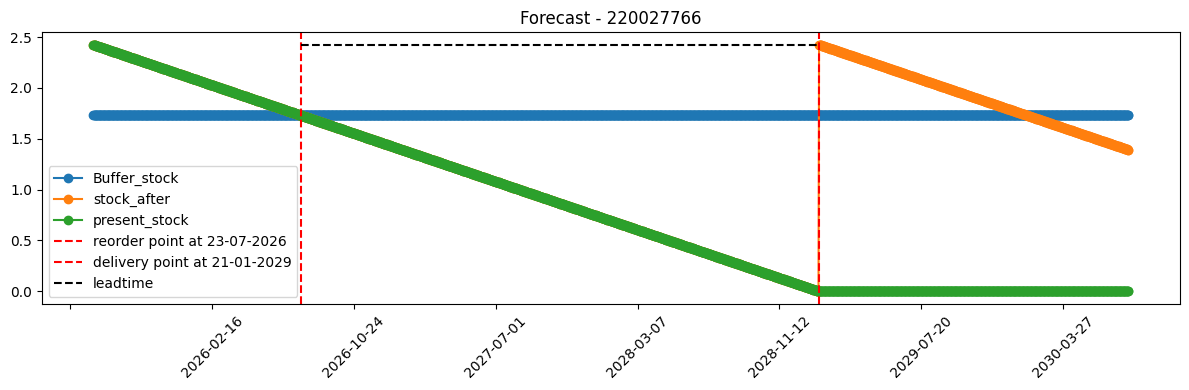

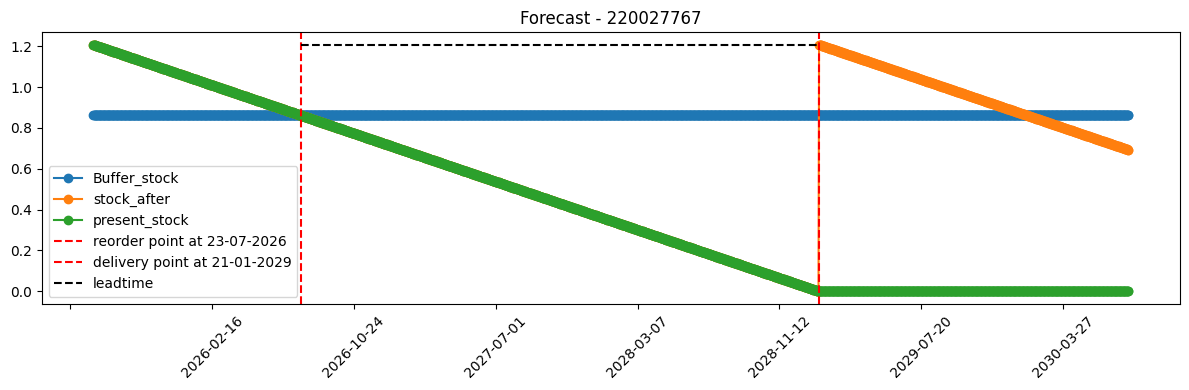

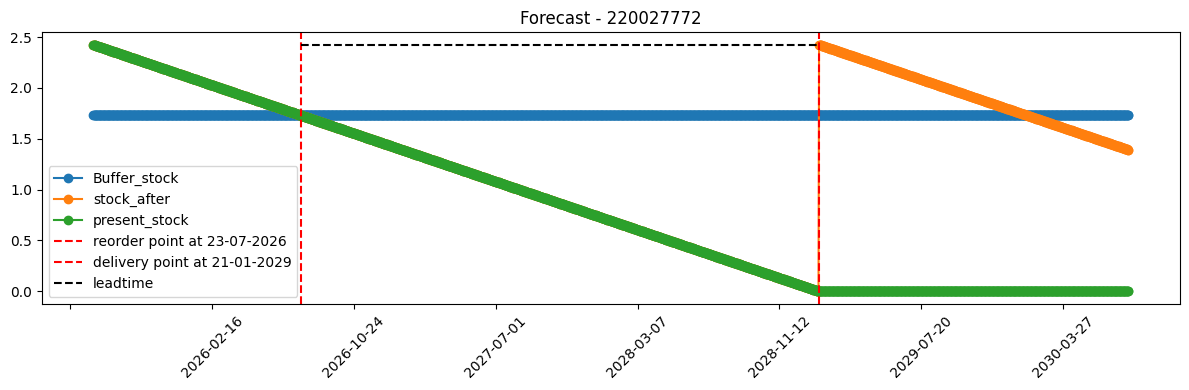

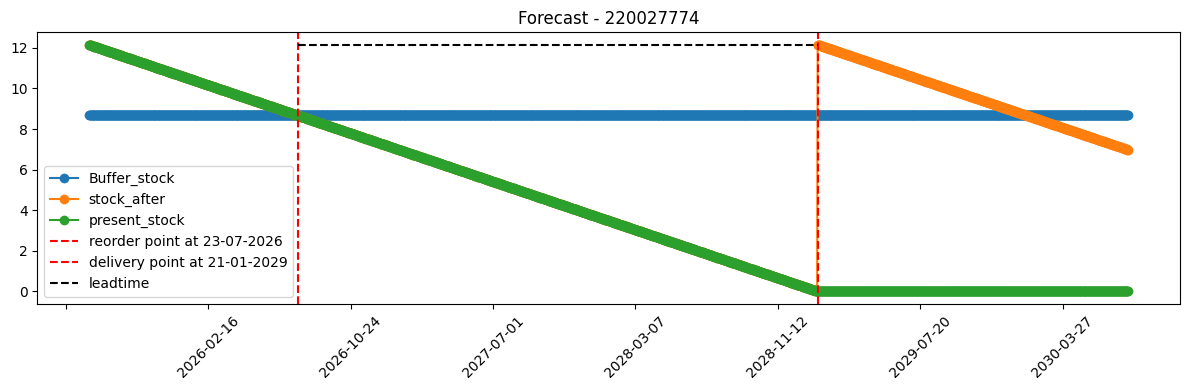

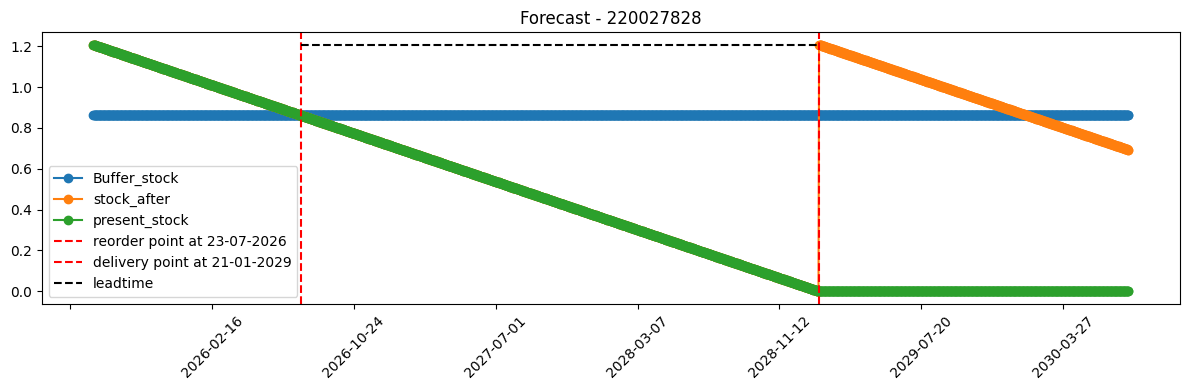

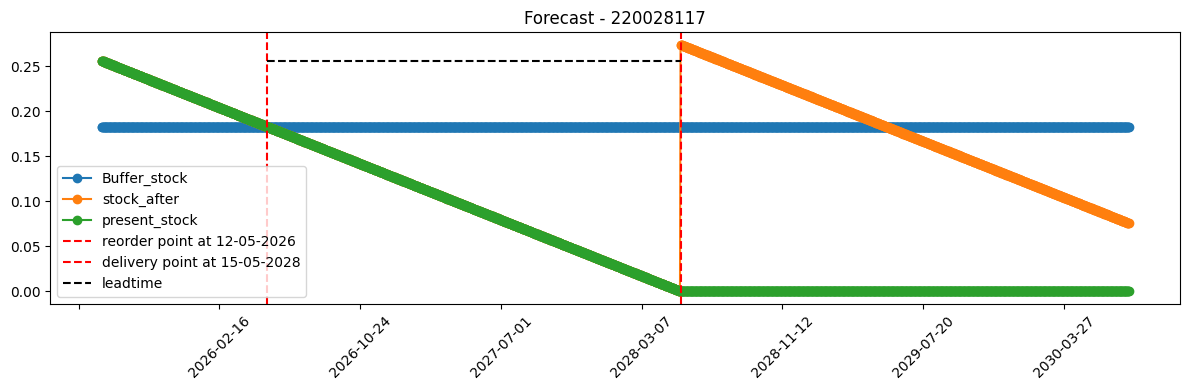

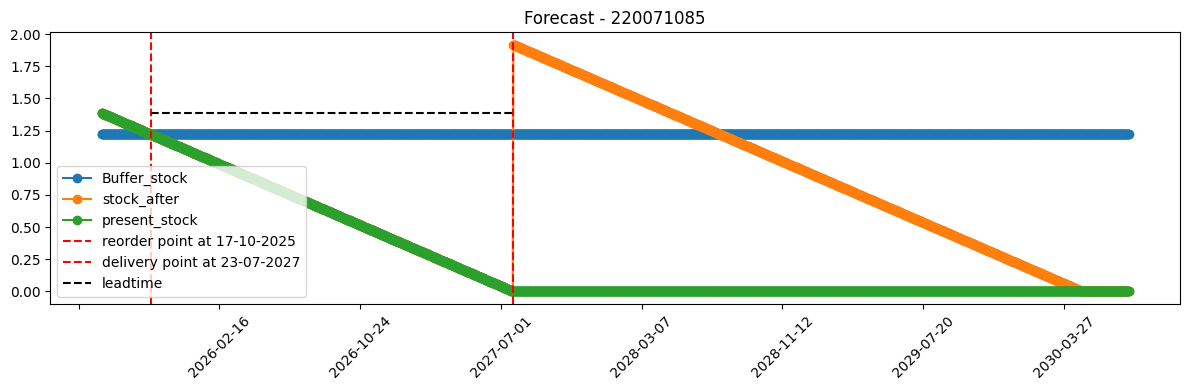

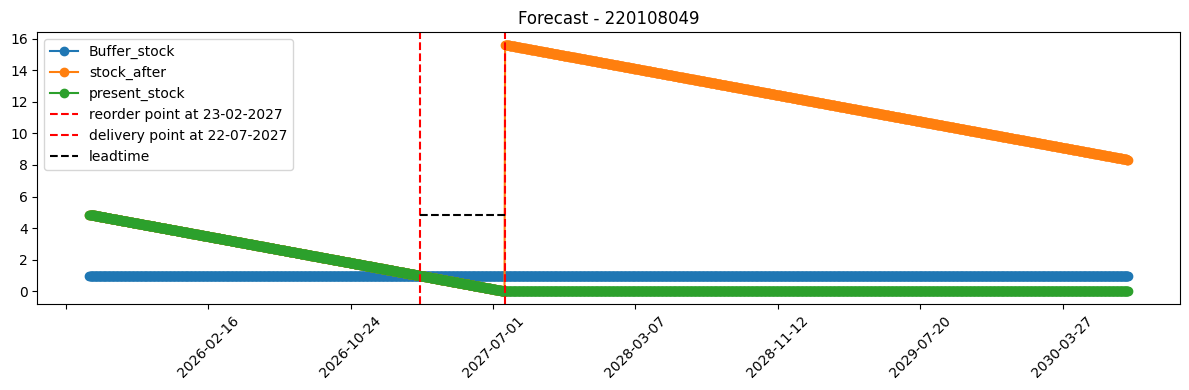

In [22]:
ordering_required={}
for mat in forecasted[forecasted.oem=='ksb'].Material.unique():
    ordering_required[mat]={}
    df, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'ksb')
    plot_req2(df,['Buffer_stock','stock_after','present_stock'],mat,ordering_required[mat]['reorder_point'],int(df.at[0,'leadtime']))

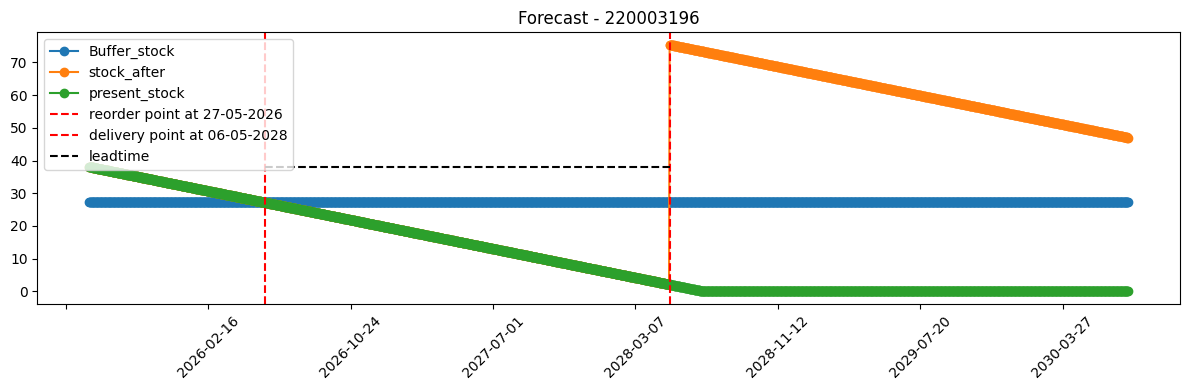

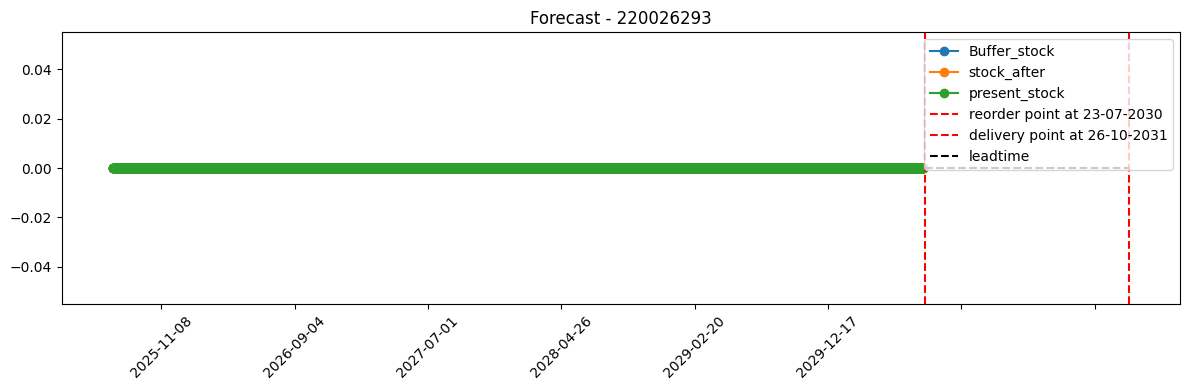

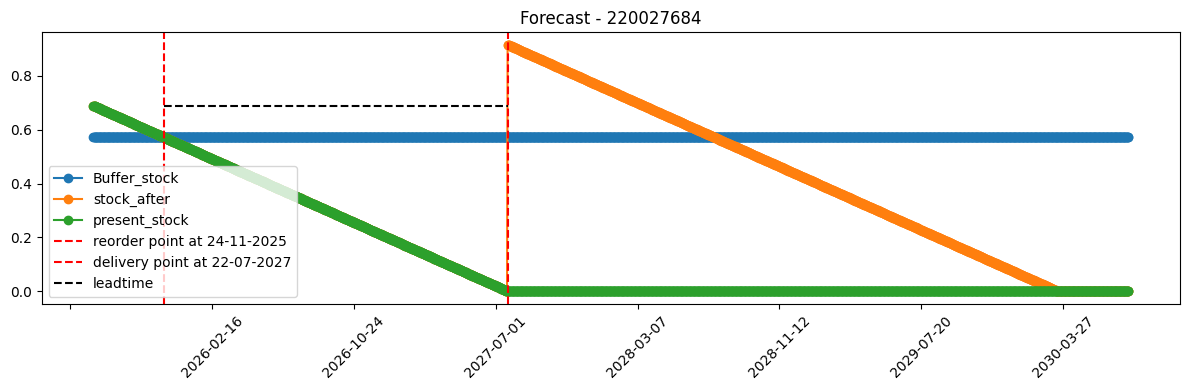

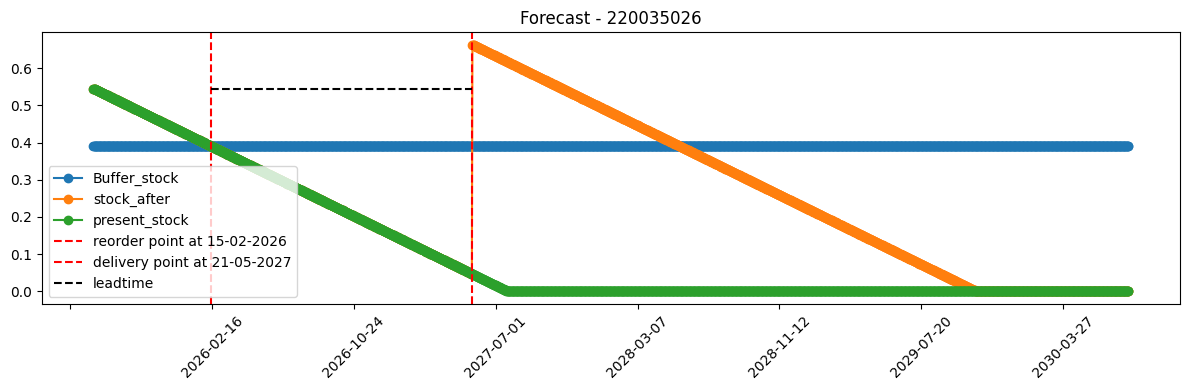

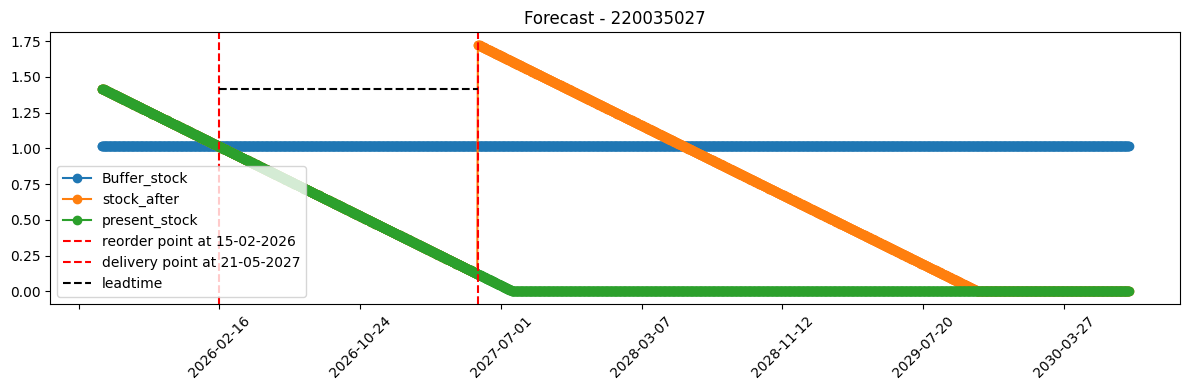

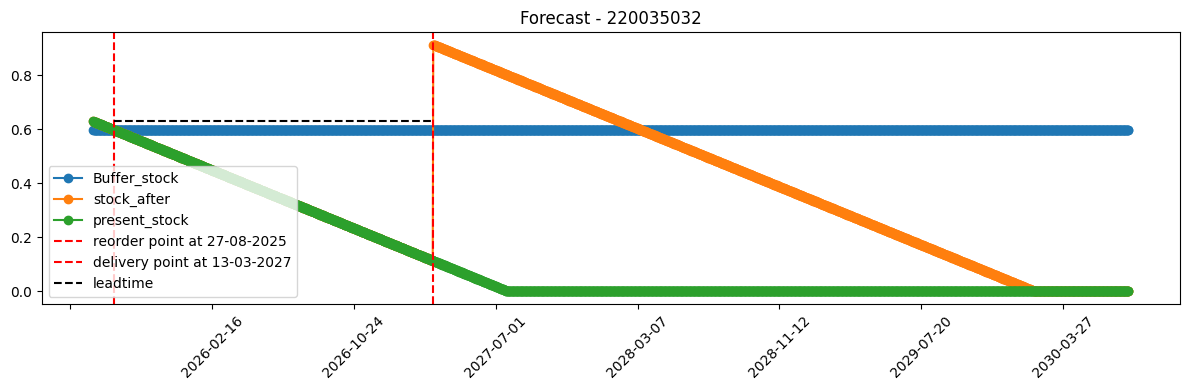

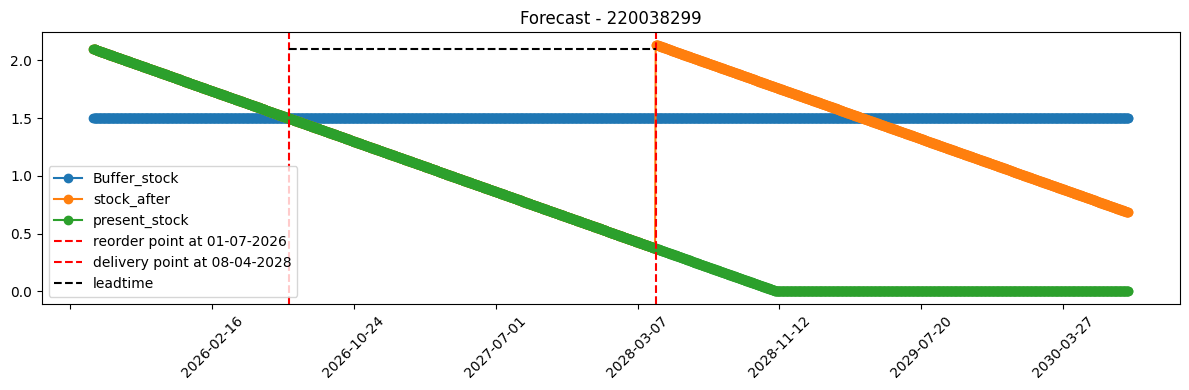

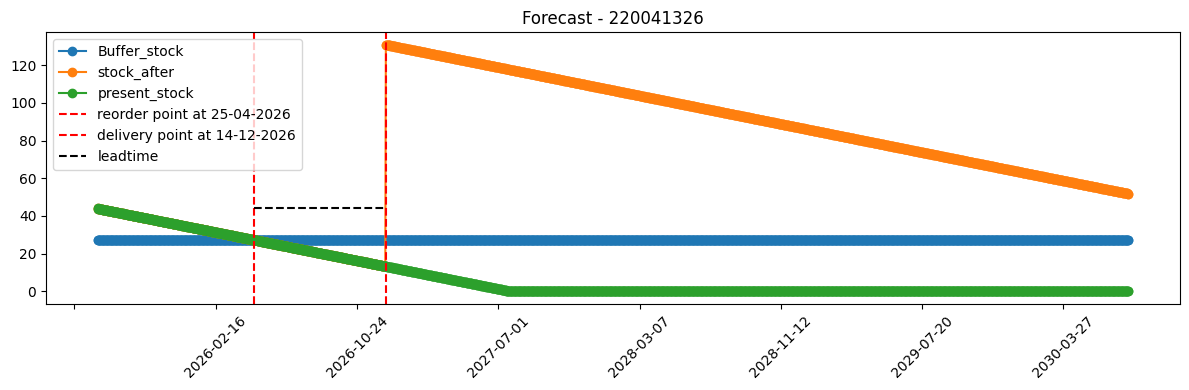

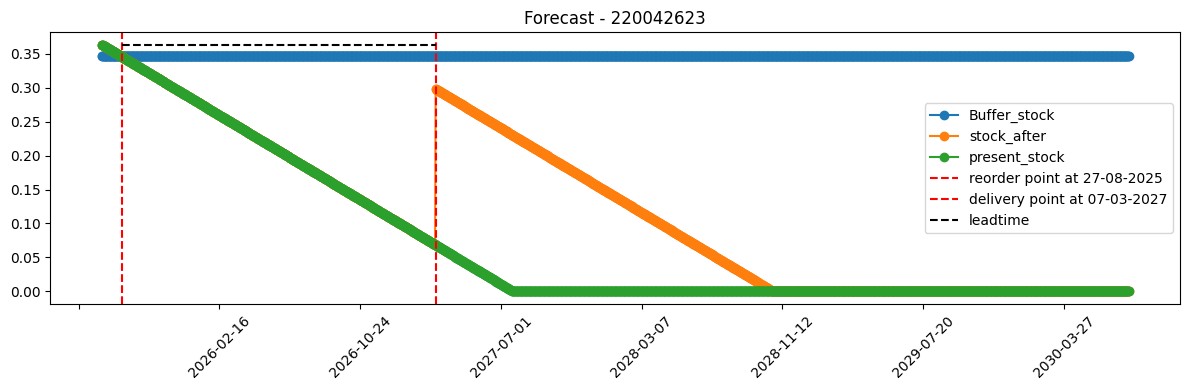

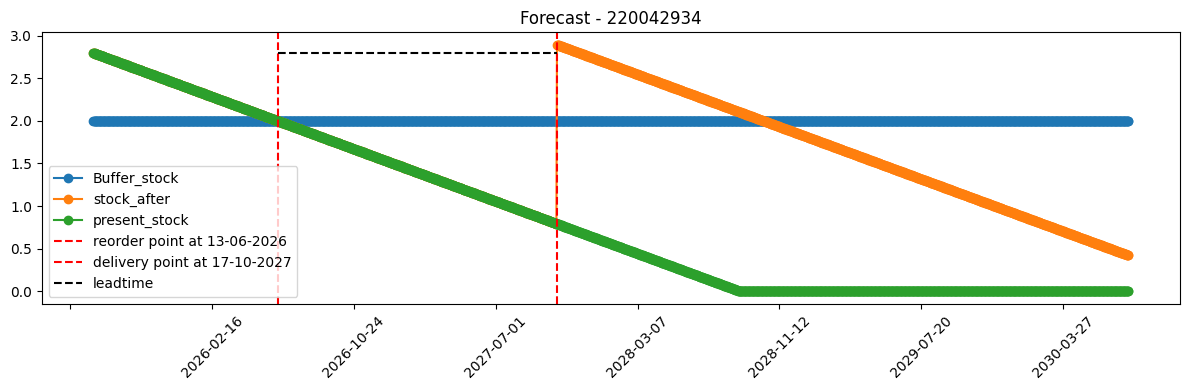

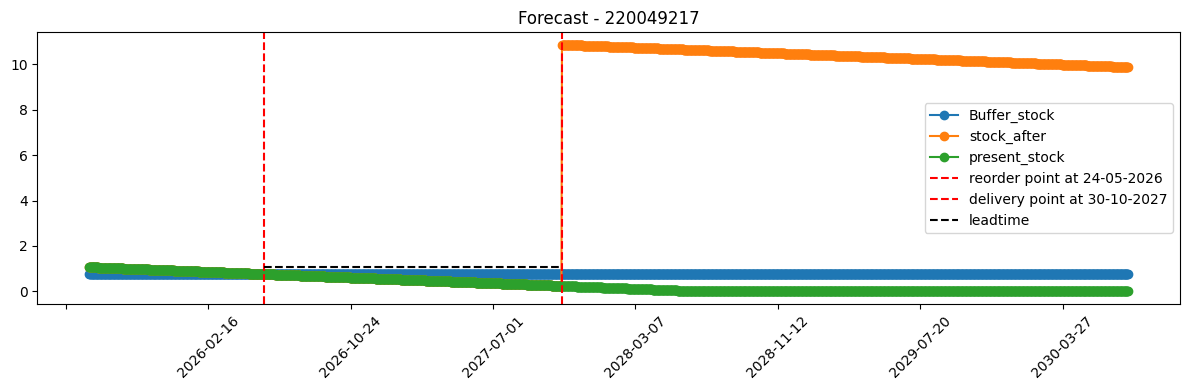

In [23]:
ordering_required={}
for mat in forecasted[forecasted.oem=='atlas'].Material.unique():
    ordering_required[mat]={}
    df, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'atlas')
    plot_req2(df,['Buffer_stock','stock_after','present_stock'],mat,ordering_required[mat]['reorder_point'],int(df.at[0,'leadtime']))

In [24]:
ordering_required

{'220003196': {'reorder_point': datetime.date(2026, 5, 27),
  'reorder_qty': 74.0,
  'updated_reorder_qty': 63.0,
  'consider_pre_order': True},
 '220026293': {'reorder_point': datetime.date(2030, 7, 23),
  'reorder_qty': 0.0,
  'updated_reorder_qty': 0.0,
  'consider_pre_order': False},
 '220027684': {'reorder_point': datetime.date(2025, 11, 24),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220035026': {'reorder_point': datetime.date(2026, 2, 15),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220035027': {'reorder_point': datetime.date(2026, 2, 15),
  'reorder_qty': 2.0,
  'updated_reorder_qty': 2.0,
  'consider_pre_order': True},
 '220035032': {'reorder_point': datetime.date(2025, 8, 27),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True},
 '220038299': {'reorder_point': datetime.date(2026, 7, 1),
  'reorder_qty': 2.0,
  'updated_reorder_qty': 2.0,
  'consider_pre_order': Tru

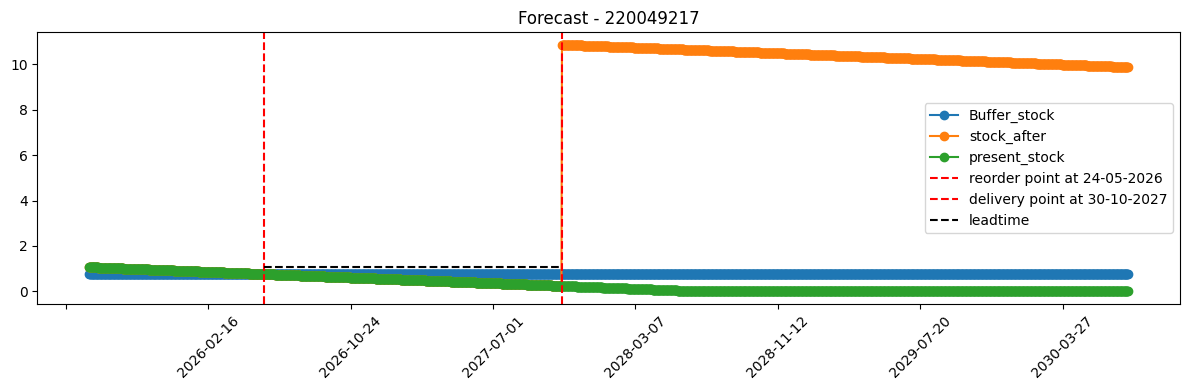

In [25]:
o_r={}
mat='220049217'
x, o_r[mat] = makedaywiseForecast(forecasted,mat,'atlas')
plot_req2(x,['Buffer_stock','stock_after','present_stock'],mat,o_r[mat]['reorder_point'],int(x.at[0,'leadtime']))

In [26]:
x

,Material,Desc,leadtime,date,daily_cons,Regular_req,One-off_req,Anticipated_consum,Buffer_stock,on_order_stock,present_stock,stock_after
0,220049217,COALESCING FILTER ELEMENT,524,2025-07-22,0.000996,4.0,0.363636,6.264508,0.760149,NaN,1.064209,1.064209
1,220049217,COALESCING FILTER ELEMENT,524,2025-07-23,0.000996,4.0,0.363636,6.264508,0.760149,NaN,1.063213,1.063213
2,220049217,COALESCING FILTER ELEMENT,524,2025-07-24,0.000996,4.0,0.363636,6.264508,0.760149,NaN,1.062217,1.062217
3,220049217,COALESCING FILTER ELEMENT,524,2025-07-25,0.000996,4.0,0.363636,6.264508,0.760149,NaN,1.06122,1.06122
4,220049217,COALESCING FILTER ELEMENT,524,2025-07-26,0.000996,4.0,0.363636,6.264508,0.760149,NaN,1.060224,1.060224
...,...,...,...,...,...,...,...,...,...,...,...,...
1820,220049217,COALESCING FILTER ELEMENT,524,2030-07-16,0.000996,4.0,0.363636,6.264508,0.760149,NaN,0,9.87995
1821,220049217,COALESCING FILTER ELEMENT,524,2030-07-17,0.000996,4.0,0.363636,6.264508,0.760149,NaN,0,9.878954
1822,220049217,COALESCING FILTER ELEMENT,524,2030-07-18,0.000996,4.0,0.363636,6.264508,0.760149,NaN,0,9.877958
1823,220049217,COALESCING FILTER ELEMENT,524,2030-07-19,0.000996,4.0,0.363636,6.264508,0.760149,NaN,0,9.876961
